In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("electric_vehicles_spec_2025.csv")

In [4]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (478, 22)
    brand                model  top_speed_kmh  battery_capacity_kWh  \
0  Abarth     500e Convertible            155                  37.8   
1  Abarth       500e Hatchback            155                  37.8   
2  Abarth  600e Scorpionissima            200                  50.8   
3  Abarth         600e Turismo            200                  50.8   
4  Aiways                   U5            150                  60.0   

  battery_type  number_of_cells  torque_nm  efficiency_wh_per_km  range_km  \
0  Lithium-ion            192.0      235.0                   156       225   
1  Lithium-ion            192.0      235.0                   149       225   
2  Lithium-ion            102.0      345.0                   158       280   
3  Lithium-ion            102.0      345.0                   158       280   
4  Lithium-ion              NaN      310.0                   156       315   

   acceleration_0_100_s  ...  towing_capacity_kg cargo_volume_l  seats  \
0    

In [19]:
# Step 3: Select Features
features = ['top_speed_kmh', 'battery_capacity_kWh', 'range_km',
'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc']

In [20]:
# Step 4: Drop rows with missing values in selected features
df = df.dropna(subset=features)
print("Rows after dropping NaN:", len(df))

Rows after dropping NaN: 477


In [21]:
X = df[features]
X


,top_speed_kmh,battery_capacity_kWh,range_km,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc
0,155,37.8,225,156,7.0,67.0
1,155,37.8,225,149,7.0,67.0
2,200,50.8,280,158,5.9,79.0
3,200,50.8,280,158,6.2,79.0
4,150,60.0,315,156,7.5,78.0
...,...,...,...,...,...,...
473,210,71.0,365,148,6.0,240.0
474,190,49.0,265,148,5.9,70.0
475,190,65.0,360,146,5.6,114.0
476,190,65.0,350,153,3.8,114.0


In [22]:
# Step 5: Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data normalized using StandardScaler")

Data normalized using StandardScaler


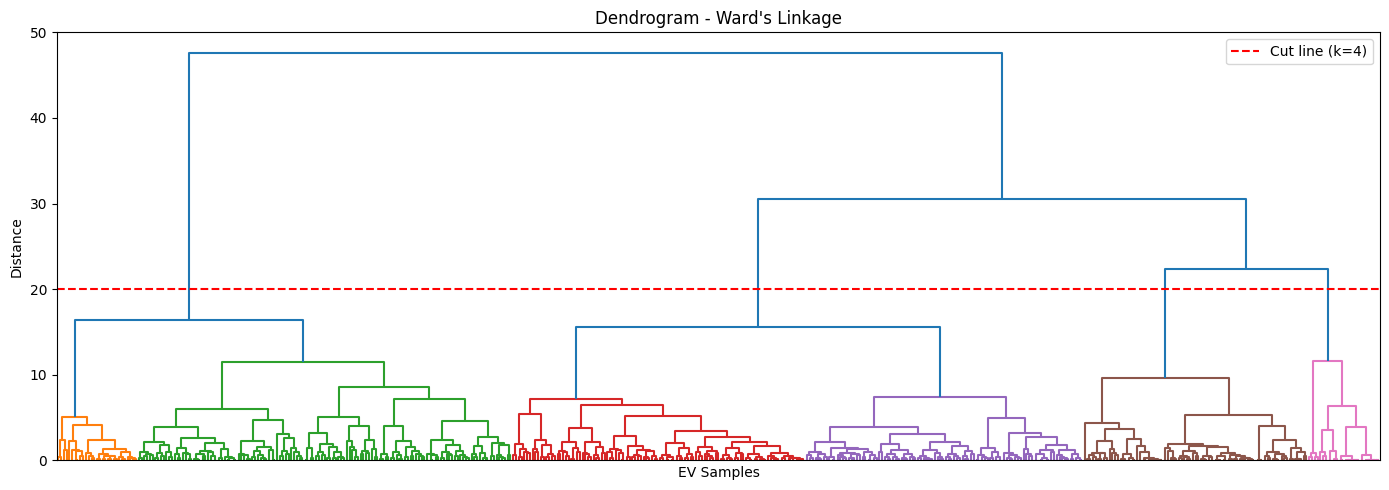

In [24]:
# Step 7: Plot Dendrogram
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=12)
plt.axhline(y=20, color='red', linestyle='--', label='Cut line (k=4)')
plt.title("Dendrogram - Ward's Linkage")
plt.xlabel("EV Samples")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
# Step 8: Fit the Model
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster'] = model.fit_predict(X_scaled)
print("\nCluster counts:")
print(df['cluster'].value_counts())


Cluster counts:
cluster
2    206
0    164
3     81
1     26
Name: count, dtype: int64


In [27]:
# Step 9: Evaluate - Silhouette Score
score = silhouette_score(X_scaled, df['cluster'])
print(f"\nSilhouette Score: {score:.4f}")



Silhouette Score: 0.2990


In [28]:
# Step 10: View Cluster Profiles
print("\nCluster Mean Profiles:")
print(df.groupby('cluster')[features].mean().round(2))


Cluster Mean Profiles:
         top_speed_kmh  battery_capacity_kWh  range_km  efficiency_wh_per_km  \
cluster                                                                        
0               221.02                 93.95    480.58                179.35   
1               138.85                 62.85    234.62                249.65   
2               178.01                 71.28    396.46                149.64   
3               148.21                 44.77    260.49                135.91   

         acceleration_0_100_s  fast_charging_power_kw_dc  
cluster                                                   
0                        4.55                     178.09  
1                       12.39                      76.38  
2                        6.78                     111.22  
3                       10.05                      68.21  


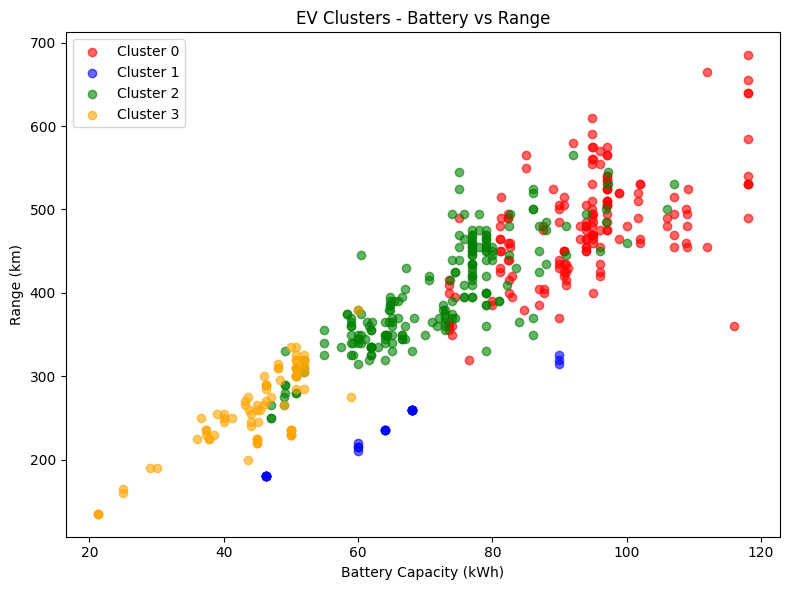

In [30]:
# Step 11: Plot Clusters using 2 features (Battery vs Range)
colors = ['red', 'blue', 'green', 'orange']
plt.figure(figsize=(8, 6))
for c in range(4):
    subset = df[df['cluster'] == c]
    plt.scatter(subset['battery_capacity_kWh'], subset['range_km'],
                label=f'Cluster {c}', color=colors[c], alpha=0.6)
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.title("EV Clusters - Battery vs Range")
plt.legend()
plt.tight_layout()
plt.show()